In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('HR_timeseries_BA_deg_10_0_SNR_40.csv')
adj_matrix = pd.read_csv('BA_Nnodes100_Adj_deg_10_0.csv', header=None)

num_nodes = adj_matrix.shape[0]
data = data.values.reshape(len(data), num_nodes, -1)[:10000]

In [3]:
from math import exp

def dx_dt(t, x, y, z, neighbors, coupling_coeffs):
    self_dynamics = lambda x, y, z: (
        -1.0001*x**3 + 2.9995*x**2 + 1.0*y - 1.0*z + 3.2416 
    )

    inter_dynamics = lambda x_i, x_j: (
        (0.29983835 - 0.149891*x_i) * (1/(1 + exp(-x_j)))
    )

    dx = self_dynamics(x, y, z)
    for a_ij, neighbor in zip(coupling_coeffs, neighbors):
        if a_ij != 0:
            dx += a_ij * inter_dynamics(x, neighbor[t, 0])
    dy = -5.0002*x**2 - 0.9999*y + 1.0002
    dz = 0.01630164*x - 0.00386712*z + 0.02545068

    return dx, dy, dz

Using device: cuda


/tmp/ipykernel_541706/1045675886.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


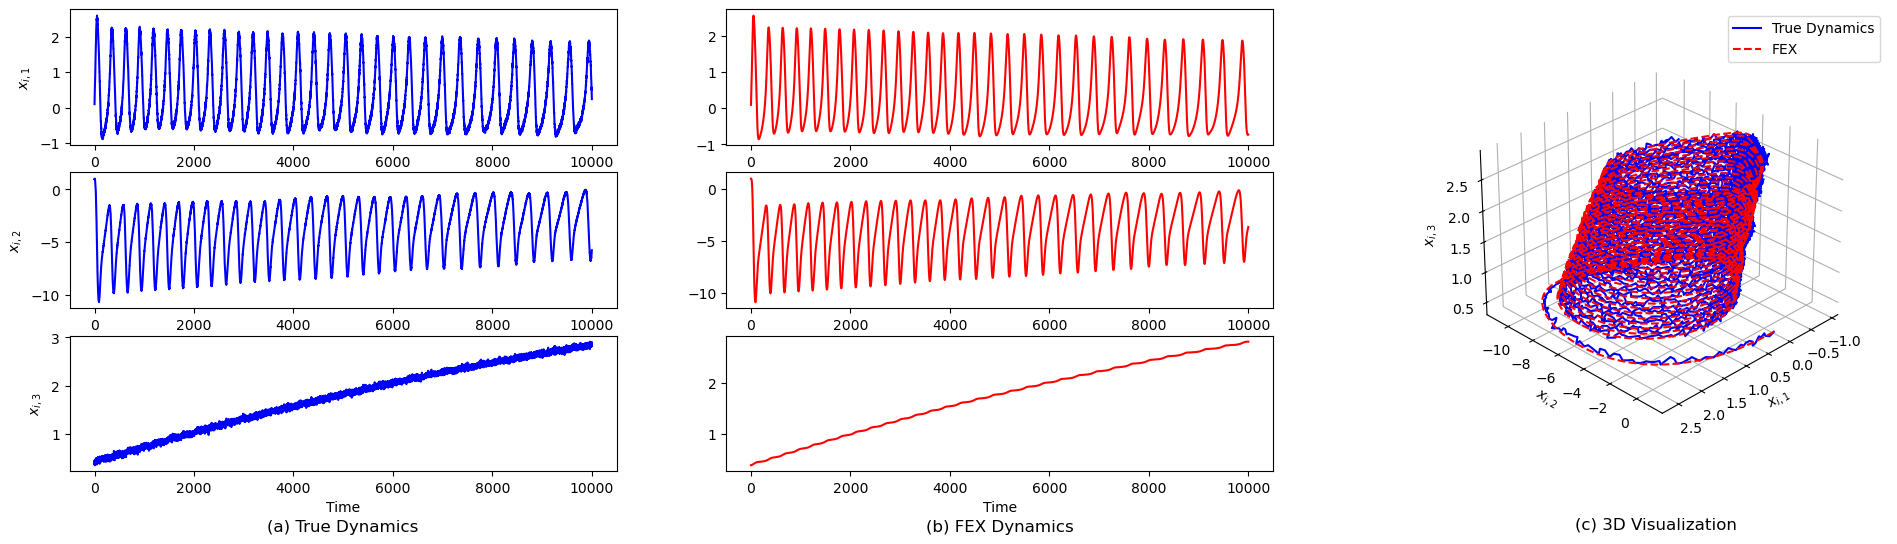

In [4]:
from FEX.utils.numerical_deriv import NumericalDeriv

node_idx = 12

dt = 0.01

true_dx_dt = NumericalDeriv(data, dt=0.01)

data_init = data[0, node_idx, :]

# Correct: shape is (num_nodes, timesteps, 3)
neighbors = np.transpose(data, (1, 0, 2))

# Correct: row for node 12, not column 12
coupling_coeffs = adj_matrix.iloc[node_idx].to_numpy(dtype=float)

x_values = data[:, node_idx, 0]
y_values = data[:, node_idx, 1]
z_values = data[:, node_idx, 2]

predicted_states = np.empty_like(data[:, node_idx, :], dtype=float)
predicted_states[0] = data[0, node_idx, :]

for t in range(len(data) - 1):
    true_current_state = data[t, node_idx]
    current_state = predicted_states[t]

    dx_dt_curr = dx_dt(
        t,
        current_state[0],
        current_state[1],
        current_state[2],
        neighbors,
        coupling_coeffs,
    )

    predicted_states[t + 1] = (
        current_state + dt * np.asarray(dx_dt_curr)
    )

from FEX.utils.plots import plot_dynamics
fig = plot_dynamics(x_values, y_values, z_values, predicted_states)
fig.show()